# README

This notebook contains analysis for different local LLMs each beoing prompted with the task generating an emails with different output length requirements.

## Links

repo: https://github.com/envite-consulting/ollama-llm-energy-measurement/tree/main

OpenAPI GMT: https://api.green-coding.io/docs#/

<hr>

## TODO

- [ ] import runs from GMT

- [ ] add interactive element to select run_ids

# Notebook

## Imports & Parameters

In [1]:
import requests
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import HTML
import numpy as np
import re
import ipywidgets as widgets

**Local imports**

In [2]:
from gmt_api_utils import fetch_measurement_data, get_run_ids, fetch_phase_stats

**Input Parameters**

In [3]:
REPOSITORY = 'https://github.com/envite-consulting/ollama-llm-energy-measurement'

In [4]:
# Add .api-key in root of repo with GMT-Api-Key
with open('../.api-key', 'r') as f:
    API_KEY = f.read().strip()

### Getting Runs

In [5]:
response = get_run_ids( 
    REPOSITORY, 
    API_KEY 
)

Request Status: 200 OK
Number of Runs: 20


### Saving in Dataframe

In [6]:
# Function to display the GMT data as a DataFrame
def display_gmt_data_as_dataframe(response):
    # Extract the 'data' property from the response
    data = response.json().get('data', [])

    # Create a DataFrame with the first 7 entries of each row
    df = pd.DataFrame(data, columns=['Run_ID', 'Name', 'Repo', 'Branch', 'Time', 'unknown', 'Usage_Scenario'] + [f'Extra_{i}' for i in range(len(data[0]) - 7)])
    df = df[['Run_ID', 'Name', 'Repo', 'Branch', 'Time', 'Usage_Scenario']]  # Keep only the required columns, excluding 'unknown'

    return df

available_runs = display_gmt_data_as_dataframe(response)

# Uncomment to see the dataframe
# available_runs  

### Selecting `run_ids`

**Relevant branches**

`branches` should contain the names of the repositories' branches that should be evaluated

In [7]:
branches = [
    'EMail Ollama Measurement Deepseek 1.5B',
    'EMail Ollama Measurement Gemma 3 4b',
    'EMail Ollama Measurement Gemma3 1b',
    'EMail Ollama Measurement Llama 3.2 3B',
    'EMail Ollama Measurement Llama 3.2 1B'
]

**Extract `run_ids` for branches**

In [8]:
def get_run_ids_by_names(name_list, dataframe, n=3):
    """
    Returns a dictionary mapping each name in name_list to a list of up to n Run_IDs from the dataframe
    whose 'Name' column contains the given name (case-insensitive).
    """
    run_ids_dict = {}
    for name in name_list:
        run_ids = dataframe[dataframe['Name'].str.contains(name, case=False, na=False)]['Run_ID'].tolist()[:n]
        run_ids_dict[name] = run_ids
    return run_ids_dict

run_ids_by_branch = get_run_ids_by_names(branches, available_runs)

run_ids_by_branch

{'EMail Ollama Measurement Deepseek 1.5B': ['72fe8e85-e503-4756-a840-41889e561288',
  'e14e9506-75ce-4a10-bc5a-e0a87748d702',
  'bd9415bf-9664-4ad5-b739-b593e7d3ff8d'],
 'EMail Ollama Measurement Gemma 3 4b': ['d5c758ac-89dd-497f-822a-f76b65984e39',
  '75299ba8-6109-4c90-9c7f-352cc9c4d870',
  'e7fdc1bc-02b9-435e-8dce-e9685b08d88a'],
 'EMail Ollama Measurement Gemma3 1b': ['fedc81ad-3caa-4ec6-9c3f-efbc0539f47c',
  '38087ab2-6f89-4e14-94f3-7771f5e1c4eb',
  '4c084331-6356-49ca-99e8-490ac62b7733'],
 'EMail Ollama Measurement Llama 3.2 3B': ['099086d9-793e-437d-86a0-e113679ec78e',
  'd10d0b34-18b1-47c0-b2e8-1ffd52aea9c8',
  'a0253185-b2bb-4b4e-8fee-cb0894536646'],
 'EMail Ollama Measurement Llama 3.2 1B': ['f751405c-a81a-4642-b8a4-321c135d8331',
  'bc6e44f4-9e65-49dc-8ce7-50b22c95b796',
  'f4bc5ea5-3a8e-4ee0-920b-d65c79e56e11']}

**Create single Dictionary containing all phase data**

In [9]:
all_phase_dataframes = []
def collect_phase_data_by_branch(branches, run_ids_by_branch):
    branch_phase_data = {}
    for branch in branches:
        run_ids = run_ids_by_branch.get(branch, [])
        run_phase_data = {}
        for run_id in run_ids:
            phase_stats = fetch_phase_stats(run_id, API_KEY)
            phase_dataframes = {}
            for phase, measurements in phase_stats.items():
                rows = []
                for measurement_name, measurement_details in measurements.items():
                    if 'data' in measurement_details:
                        for component_name, component_details in measurement_details['data'].items():
                            for run_id_inner, run_data in component_details['data'].items():
                                rows.append({
                                    'Name': measurement_name,
                                    'Component': component_name,
                                    'Type': measurement_details['type'],
                                    'Unit': measurement_details['unit'],
                                    'Value': run_data['mean']
                                })
                phase_dataframes[phase] = pd.DataFrame(rows)
            run_phase_data[run_id] = phase_dataframes
        branch_phase_data[branch] = run_phase_data
    return branch_phase_data

branch_phase_data = collect_phase_data_by_branch(branches, run_ids_by_branch)

**Reduce to relevant metrics**

`relevant_measurements` should contain the names of the metrics that are relevant moving forward. 

In [10]:
relevant_measurements = [
    'phase_time_syscall_system',
    'cpu_energy_rapl_msr_component',
    'cpu_utilization_procfs_system',
    'gpu_energy_nvidia_nvml_component',
    'memory_energy_rapl_msr_component',
    'psu_energy_ac_mcp_machine',
]

`phase_identifier` is the string that all phases to be evaluated have in common

In [11]:
phase_identifier = "Run email generation"

In [12]:
def filter_branch_phase_data(branch_phase_data, relevant_measurements):
    """
    Reduces each dataframe in branch_phase_data to only those rows whose 'Name' is in relevant_measurements.
    Returns a new dictionary with the same structure as branch_phase_data.
    """
    filtered = {}
    for branch, runs in branch_phase_data.items():
        filtered[branch] = {}
        for run_id, phase_data in runs.items():
            filtered[branch][run_id] = {}
            for phase, df in phase_data.items():
                if not df.empty and 'Name' in df.columns:
                    filtered_df = df[df['Name'].isin(relevant_measurements)].copy()
                else:
                    filtered_df = df
                filtered[branch][run_id][phase] = filtered_df
    return filtered

metric_filtered_branch_phase_data = filter_branch_phase_data(branch_phase_data, relevant_measurements)

In [13]:
def filter_phases_with_email_generation(branch_metric_phase_data, phase_identifier):
    """
    Filters a nested dictionary of branch -> run_id -> phase_name -> df
    to only include phases whose names contain "Run email generation".
    """
    filtered = {}
    for branch, runs in branch_metric_phase_data.items():
        filtered[branch] = {}
        for run_id, phases in runs.items():
            filtered_phases = {phase: df for phase, df in phases.items() if phase_identifier in phase}
            if filtered_phases:
                filtered[branch][run_id] = filtered_phases
        if not filtered[branch]:
            del filtered[branch]
    return filtered

phase_filtered_branch_phase_data = filter_phases_with_email_generation(metric_filtered_branch_phase_data, phase_identifier)

In [14]:
selected_metric = 'psu_energy_ac_mcp_machine'

In [15]:
def aggregate_phase_metrics_by_branch(phase_filtered_branch_phase_data):
    """
    For each branch in phase_filtered_branch_phase_data, aggregates the metrics for each phase across all runs.
    Returns a dictionary: {branch: {phase: mean_df}}
    Each mean_df contains the mean of each metric for that phase across all runs in the branch.
    """
    result = {}
    for branchname, branchcontent in phase_filtered_branch_phase_data.items():
        run_means = {}
        for run_id, run_id_content in branchcontent.items():
           phases = {}
           for phase_name, phase_df in run_id_content.items():
               phases[phase_name] = []
           for phase_name, phase_df in run_id_content.items():
               phases[phase_name].append(phase_df)
           for phase_name, phase_list in phases.items():
                combined = pd.concat(phase_list, ignore_index=True)
                group_cols = [col for col in combined.columns if col != 'Value']
                mean_df = combined.groupby(group_cols, as_index=False)['Value'].mean()
                if branchname not in result:
                    result[branchname] = {}
                if phase_name not in result[branchname]:
                    result[branchname][phase_name] = mean_df
                run_means[phase_name] = mean_df
        result[branchname] = run_means
    return result
           
aggregated_phase_data = aggregate_phase_metrics_by_branch(phase_filtered_branch_phase_data)

In [16]:
aggregated_phase_data

{'EMail Ollama Measurement Deepseek 1.5B': {'Run email generation prompt with length condition 16 words':                                Name                  Component   Type   Unit  \
  0     cpu_energy_rapl_msr_component                  Package_0  TOTAL     uJ   
  1     cpu_utilization_procfs_system                   [SYSTEM]   MEAN  Ratio   
  2  gpu_energy_nvidia_nvml_component  NVIDIA GeForce GTX 1080-0  TOTAL     uJ   
  3  memory_energy_rapl_msr_component                     DRAM_0  TOTAL     uJ   
  4         phase_time_syscall_system                   [SYSTEM]  TOTAL     us   
  5         psu_energy_ac_mcp_machine                  [MACHINE]  TOTAL     uJ   
  
           Value  
  0   68145982.0  
  1       1759.0  
  2  460647583.0  
  3    2235884.0  
  4    2774165.0  
  5  644907594.0  ,
  'Run email generation prompt with length 32 words':                                Name                  Component   Type   Unit  \
  0     cpu_energy_rapl_msr_component              

In [17]:
def create_metric_matrix(aggregated_phase_data, selected_metric):
    """
    Creates a dataframe with branches as rows and phases as columns.
    Each cell contains the 'Value' for the selected_metric from the corresponding phase dataframe.
    
    Parameters:
        aggregated_phase_data (dict): Nested dict {branch: {phase: df}}
        selected_metric (str): Name of the metric to extract from each phase dataframe.
    
    Returns:
        pd.DataFrame: DataFrame with branches as index, phases as columns, and metric values as cells.
    """

    matrix = {}
    # Collect all unique phase names
    all_phases = set()
    for branch_data in aggregated_phase_data.values():
        all_phases.update(branch_data.keys())
    all_phases = sorted(all_phases)

    for branch, phase_dict in aggregated_phase_data.items():
        row = {}
        for phase in all_phases:
            df = phase_dict.get(phase)
            if df is not None and not df.empty:
                metric_row = df[df['Name'] == selected_metric]
                if not metric_row.empty:
                    row[phase] = metric_row['Value'].values[0]
                else:
                    row[phase] = None
            else:
                row[phase] = None
        matrix[branch] = row

    return pd.DataFrame.from_dict(matrix, orient='index', columns=all_phases)

# Example usage:
metric_matrix = create_metric_matrix(aggregated_phase_data, selected_metric)

metric_matrix

,Run email generation prompt with length 32 words,Run email generation prompt with length condition 1024 words,Run email generation prompt with length condition 128 words,Run email generation prompt with length condition 16 words,Run email generation prompt with length condition 2056 words,Run email generation prompt with length condition 256 words,Run email generation prompt with length condition 512 words,Run email generation prompt with length condition 64 words
EMail Ollama Measurement Deepseek 1.5B,900336913.0,2.196031e+09,8.537500e+08,644907594.0,1.760746e+09,1.456607e+09,1.272102e+09,1.287657e+09
EMail Ollama Measurement Gemma 3 4b,404187002.0,5.091683e+09,1.124503e+09,236747518.0,4.657385e+09,1.477008e+09,2.309062e+09,6.412100e+08
EMail Ollama Measurement Gemma3 1b,178311231.0,2.168353e+09,3.016698e+08,131345281.0,3.563825e+09,8.187599e+08,1.293240e+09,2.523791e+08
EMail Ollama Measurement Llama 3.2 3B,289874449.0,9.629001e+08,6.500831e+08,134068370.0,1.192741e+09,1.047824e+09,2.492297e+09,4.156827e+08
EMail Ollama Measurement Llama 3.2 1B,178173397.0,7.251423e+08,3.292974e+08,120842465.0,9.189783e+08,5.819891e+08,7.184890e+08,2.180033e+08


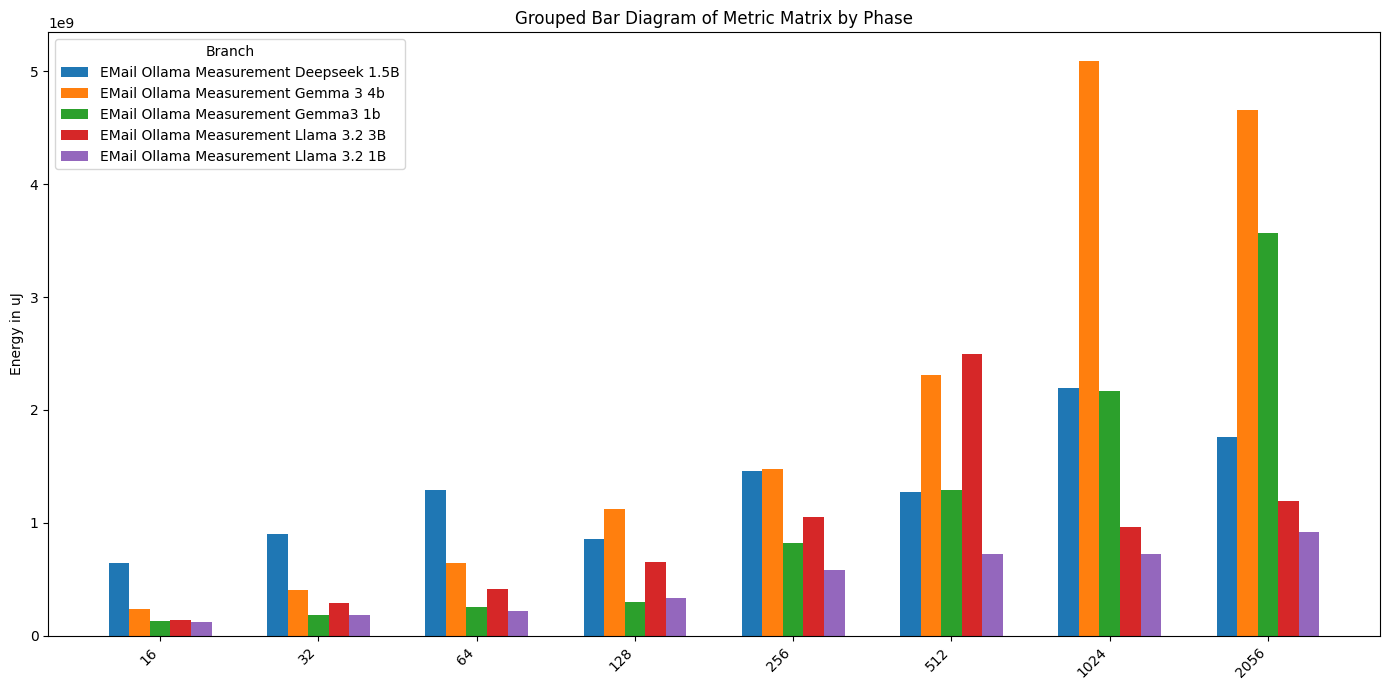

In [ ]:
# Use a colorblind-friendly palette
color_palette = plt.get_cmap('tab10')

fig, ax = plt.subplots(figsize=(14, 7))

branches = metric_matrix.index.tolist()
phases = metric_matrix.columns.tolist()

# Extract numeric word lengths for sorting
phase_word_lengths = []
for phase in phases:
    match = re.search(r'(\d+)\s*words', phase)
    if match:
        phase_word_lengths.append(int(match.group(1)))
    else:
        phase_word_lengths.append(float('inf'))

# Sort phases by word length
sorted_indices = np.argsort(phase_word_lengths)
sorted_phases = [phases[i] for i in sorted_indices]
sorted_word_labels = [str(phase_word_lengths[i]) if phase_word_lengths[i] != float('inf') else phases[i] for i in sorted_indices]
x = np.arange(len(sorted_phases))
bar_width = 0.13

for i, branch in enumerate(branches):
    values = metric_matrix.loc[branch][sorted_phases].values
    ax.bar(x + i * bar_width, values, width=bar_width, label=branch, color=color_palette(i % 10))

ax.set_xticks(x + bar_width * (len(branches) - 1) / 2)
ax.set_xticklabels(sorted_word_labels, rotation=45, ha='right')
ax.set_ylabel('Energy in uJ')
ax.set_title('Energy Consumption by model grouped by output token length')
ax.legend(title='Branch')
plt.tight_layout()
plt.show()
